In [2]:

import logging
from pathlib import Path

import numpy as np
import polars as pl
import pandas as pd
# from decimal import Decimal
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

from typing import Optional, Tuple



In [3]:
# ============================================================================
# [START] - Polars Display Configurations
# ============================================================================

pl.Config.set_tbl_rows(1000)      # show up to 100 rows
pl.Config.set_tbl_cols(50)       # show up to 50 columns
# pl.Config.set_tbl_width_chars(0) # 0 = no width limit
pl.Config.set_tbl_hide_dataframe_shape(False)  # keep shape info

# [ DEFAULT DECIMAL DISPLAY ]
# # Option 1: Set display precision globally
# pl.Config.set_fmt_float("full")

# Option 2: Set specific decimal places
# pl.Config.set_float_precision(7)

# # Option 3: Check individual values
# print(result["price_decimal"][7])  # Will show: 0.0070995

# ============================================================================
# [END] - Polars Display Configurations
# ============================================================================

polars.config.Config

In [4]:

class AvailableDatasets:
    """Available Datasets, returns request ID"""

    FULL_YEAR_2024__CME_JPY_V: str = "GLBX-20251028-HAE9P7SP3U"
    FULL_YEAR_2023__CME_JPY_V: str = "GLBX-20251116-MJ5JKQA9A4"
    FULL_YEAR_2022__CME_JPY_V: str = "GLBX-20251115-DJHUGKSLWB"


In [5]:

# WORKING DIRECTORY
MAIN_DIR = Path("/Users/number6/Projects/Bimini/")

# HISTORICAL DATA
HISTORICAL_DATA = MAIN_DIR / "0_data" / "historical"

# IMPORT PATH
PARQUET_DIR = HISTORICAL_DATA / "parquet"

# EXPORT PATH
EXPORT_DIR = MAIN_DIR / "journal_results"


In [6]:


"""

?

"""



TICK_SIZE = 0.00001




# Convert START_DATE and END_DATE to nanosecond epochs (integers)
START_DATE_NS = int(
    datetime(
        year=2022,
        month=10,
        day=27,
        hour=8,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)

END_DATE_NS = int(
    datetime(
        year=2022,
        month=11,
        day=14,
        hour=18,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)


hrf_start_dt = datetime.fromtimestamp(START_DATE_NS / 1e9, tz=timezone.utc)
hrf_end_dt = datetime.fromtimestamp(END_DATE_NS / 1e9, tz=timezone.utc)

print("START_DATE_NS", hrf_start_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))
print("END_DATE_NS", hrf_end_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))


"""

Rolling average container

Container_Size > Search_Range

Thus only consider end time for each new interval of the rolling average that would be available in the time frame


"""



START_DATE_NS 2022-10-27 08:00:00 UTC
END_DATE_NS 2022-11-14 18:00:00 UTC


'\n\nRolling average container\n\nContainer_Size > Search_Range\n\nThus only consider end time for each new interval of the rolling average that would be available in the time frame\n\n\n'

In [7]:

BUCKET_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/2313_Nov_21_25/bucket/fixed/bucket_fixed_consolidated.parquet")

# Data files to glob for processing
BUCKET_DATA_GLOB = pl.scan_parquet(str(BUCKET_DIR))

# Schema? ...


In [8]:
VOLUME_BAR_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/2313_Nov_21_25/bucket/fixed/bucket_fixed_consolidated.parquet")

# Data files to glob for processing
VOLUME_BAR_DATA_GLOB = pl.scan_parquet(str(VOLUME_BAR_DIR))

# Schema? ...


In [9]:
"""

DATASET FILTERED FOR EVENT

VolumeBar, used for price plots(?)

"""


# event__vb_lf = (
#     VOLUME_BAR_DATA_GLOB
#     .filter(
#         (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
#         (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
#     )
#     .with_columns([
#         pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
#     ])
# ).collect()


'\n\nDATASET FILTERED FOR EVENT\n\nVolumeBar, used for price plots(?)\n\n'

In [10]:
"""

DATASET FILTERED FOR EVENT

bucket, used for price plots(?)

"""

# fb_lf = (
#     BUCKET_DATA_GLOB
#     .with_columns(
#         (pl.col("active_imbalance_abs").rank(method="average").truediv(pl.len()) * 100).alias("a"),
#         (pl.col("passive_imbalance_abs").rank(method="average").truediv(pl.len()) * 100).alias("b"),
#     )
#     # .collect()  # Force rank computation over full dataset
#     # .lazy()
#     .filter(
#         (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
#         (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
#     )
#     # .select([
#     #     "id",
#     #     pl.col("end_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("end_ts_ns"),
#     # ])
#     .with_columns([
#         pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
#         # (pl.col("time_elapsed_ns_mean") / 1e9).alias("time_elapsed_ns_mean"),
#     ])
# ).collect()

# print(fb_lf["a"])


'\n\nDATASET FILTERED FOR EVENT\n\nbucket, used for price plots(?)\n\n'

In [11]:
def plot_price_with_metrics(
    main_df: pl.DataFrame,
    main_ts_col: str,
    main_col: str,
    metrics_df: pl.DataFrame,
    metrics_ts_col: str,
    metric_cols: list[str],
    metric_labels: Optional[list[str]] = None,
    main_range: Tuple[Optional[float], Optional[float]] = (None, None),
    metric_range: Tuple[Optional[float], Optional[float]] = (None, None),
    main_range_padding: Tuple[float, float] = (0.0, 0.0),
    metric_range_padding: Tuple[float, float] = (0.0, 0.0),
    title: str = "Main Series vs. Metrics",
    main_label: str = "Main Series",
    main_symbol: str = "",
    main_symbol_prefix: bool = True,
    main_decimal_places: Optional[int] = None,
    show_calculation_guides: bool = True,
    step_lines: bool = True,
    event_a_col: str = "",
    event_a_label: str = "Event A",
    event_b_col: str = "",
    event_b_label: str = "Event B",
    show_time_labels: bool = True,
    rotate_time_labels: Optional[float] = None,
    time_label_interval_hours: Optional[int] = None,
    time_label_format: str = 'auto',
    time_label_max_count: Optional[int] = None,
    figsize: Tuple[int, int] = (16, 10),
) -> Tuple[plt.Figure, Tuple[plt.Axes, plt.Axes]]:
    """
    Plot a main time series with 1-4 metric time series on a dual-axis chart.
    
    Parameters
    ----------
    main_df : pl.DataFrame
        DataFrame containing main series data with nanosecond epoch timestamps.
    main_ts_col : str
        Column name for main series timestamps (nanosecond epoch).
    main_col : str
        Column name for main series values.
    metrics_df : pl.DataFrame
        DataFrame containing metric data with shared timestamps.
    metrics_ts_col : str
        Column name for metric timestamps (nanosecond epoch).
    metric_cols : list[str]
        List of 1-4 column names for metrics to plot.
    metric_labels : list[str], optional
        Display labels for metrics. Defaults to column names.
    main_range : tuple[float | None, float | None]
        Y-axis range for main series: (min, max). Use (None, None) for auto-calculation.
    metric_range : tuple[float | None, float | None]
        Y-axis range for metrics: (min, max). Use (None, None) for auto-calculation.
    main_range_padding : tuple[float, float]
        Absolute padding to add to main range: (lower_bound, upper_bound).
    metric_range_padding : tuple[float, float]
        Absolute padding to add to metric range: (lower_bound, upper_bound).
    title : str
        Chart title.
    main_label : str
        Label for main series in legend.
    main_symbol : str
        Symbol to display with main axis values (e.g., "$", "€", "¥"). Empty string for no symbol.
    main_symbol_prefix : bool
        If True, symbol appears before value. If False, symbol appears after value.
    main_decimal_places : int, optional
        Number of decimal places for main axis. None for auto-determination.
    show_calculation_guides : bool
        Whether to show calculation point markers and vertical interval lines.
    step_lines : bool
        If True, draw step function (horizontal lines held constant).
        If False, draw thin lines connecting calculation points.
    event_a_col : str
        Column name for event A boolean flags. Empty string disables feature.
    event_a_label : str
        Legend label for event A regions.
    event_b_col : str
        Column name for event B boolean flags. Empty string disables feature.
    event_b_label : str
        Legend label for event B regions.
    show_time_labels : bool
        Whether to display time labels on X-axis.
    rotate_time_labels : float, optional
        Rotation angle for time labels in degrees. None uses 0° for horizontal.
        Common values: 0 (horizontal), 45 (diagonal), 90 (vertical).
    time_label_interval_hours : int, optional
        Interval between time labels in hours. None for auto-determination.
    time_label_format : str
        Format for time labels. Options: 'auto', 'time_only', 'date_only', 'full',
        or custom strftime format string (e.g., '%H:%M' or '%Y-%m-%d').
    time_label_max_count : int, optional
        Maximum number of time labels to display. Overrides interval if set.
    figsize : tuple[int, int]
        Figure dimensions.
    
    Returns
    -------
    tuple[plt.Figure, tuple[plt.Axes, plt.Axes]]
        Figure and (main_axis, metrics_axis) tuple.
        
    Notes
    -----
    Time label priority hierarchy:
    1. show_time_labels=False → No labels shown
    2. time_label_max_count → Determines interval to meet max count
    3. time_label_interval_hours → Uses specified interval
    4. Auto-determination → Based on data timespan
    """
    if not 1 <= len(metric_cols) <= 4:
        raise ValueError("metric_cols must contain 1 to 4 column names")
    
    if metric_labels is None:
        metric_labels = metric_cols
    
    if len(metric_labels) != len(metric_cols):
        raise ValueError("metric_labels must match length of metric_cols")
    
    # Apply Bloomberg theme
    plt.rcParams.update({
        'figure.facecolor': '#0a0e27',
        'axes.facecolor': '#0f1419',
        'axes.edgecolor': '#1e2332',
        'axes.labelcolor': '#b3b8c4',
        'axes.titlecolor': '#ffffff',
        'text.color': '#e8eaed',
        'xtick.color': '#7e8391',
        'ytick.color': '#7e8391',
        'grid.color': '#1e2332',
        'grid.linestyle': '--',
        'grid.linewidth': 0.5,
        'grid.alpha': 0.3,
        'figure.dpi': 150,
        'axes.grid': True,
        'axes.axisbelow': True,
        'font.family': 'sans-serif',
        'font.size': 10,
        'axes.titlesize': 14,
        'axes.titleweight': 'bold',
        'lines.linewidth': 2.5,
    })
    
    # Metric color palette (up to 4 colors)
    metric_colors = ['#ffd93d', '#ff6b6b', '#a29bfe', '#4ecdc4']
    
    # Event colors
    event_a_color = '#4ecdc4'  # Bright cyan/blue
    event_b_color = '#ff6b9d'  # Bright purple-pink
    
    # Convert main series data
    main_df_plot = main_df.with_columns(
        pl.from_epoch(pl.col(main_ts_col), time_unit="ns").alias("_ts_dt")
    )
    main_pd = main_df_plot.select(["_ts_dt", main_col]).to_pandas()
    main_pd = main_pd.sort_values("_ts_dt")
    
    # Convert metrics data
    metrics_cols_to_select = ["_ts_dt", "start_ts_ns", "end_ts_ns"] + metric_cols
    if event_a_col:
        metrics_cols_to_select.append(event_a_col)
    if event_b_col:
        metrics_cols_to_select.append(event_b_col)
    
    metrics_df_plot = metrics_df.with_columns([
        pl.from_epoch(pl.col(metrics_ts_col), time_unit="ns").alias("_ts_dt"),
        pl.from_epoch(pl.col("start_ts_ns"), time_unit="ns").alias("_start_dt"),
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("_end_dt"),
    ])
    
    metrics_cols_to_select_final = ["_ts_dt", "_start_dt", "_end_dt"] + metric_cols
    if event_a_col:
        metrics_cols_to_select_final.append(event_a_col)
    if event_b_col:
        metrics_cols_to_select_final.append(event_b_col)
    
    metrics_pd = metrics_df_plot.select(metrics_cols_to_select_final).to_pandas()
    metrics_pd = metrics_pd.sort_values("_ts_dt")
    
    # Calculate data timespan for auto-formatting
    time_min = main_pd["_ts_dt"].min()
    time_max = main_pd["_ts_dt"].max()
    timespan_hours = (time_max - time_min).total_seconds() / 3600
    
    # Calculate main range if needed
    if main_range[0] is None or main_range[1] is None:
        main_min = main_pd[main_col].min()
        main_max = main_pd[main_col].max()
        main_range = (main_min, main_max)
    
    # Apply padding to main range
    final_main_min = main_range[0] - main_range_padding[0]
    final_main_max = main_range[1] + main_range_padding[1]
    
    # Calculate metric range if needed
    if metric_range[0] is None or metric_range[1] is None:
        all_metric_values = []
        for col in metric_cols:
            all_metric_values.extend(metrics_pd[col].values)
        metric_min = min(all_metric_values)
        metric_max = max(all_metric_values)
        metric_range = (metric_min, metric_max)
    
    # Apply padding to metric range
    final_metric_min = metric_range[0] - metric_range_padding[0]
    final_metric_max = metric_range[1] + metric_range_padding[1]
    
    # Auto-determine decimal places for main axis if not specified
    if main_decimal_places is None:
        main_data_range = main_range[1] - main_range[0]
        if main_data_range >= 100:
            main_decimal_places = 0
        elif main_data_range >= 10:
            main_decimal_places = 1
        elif main_data_range >= 1:
            main_decimal_places = 2
        elif main_data_range >= 0.1:
            main_decimal_places = 3
        elif main_data_range >= 0.01:
            main_decimal_places = 4
        else:
            main_decimal_places = 5
    
    # Build list of event time ranges where lines should be discontinuous
    event_ranges = []
    if event_a_col:
        event_a_rows = metrics_pd[metrics_pd[event_a_col] == True]
        for _, row in event_a_rows.iterrows():
            event_ranges.append((row["_start_dt"], row["_end_dt"]))
    if event_b_col:
        event_b_rows = metrics_pd[metrics_pd[event_b_col] == True]
        for _, row in event_b_rows.iterrows():
            event_ranges.append((row["_start_dt"], row["_end_dt"]))
    
    # Helper function to check if a timestamp is within any event range
    def is_in_event(timestamp):
        for start, end in event_ranges:
            if start <= timestamp <= end:
                return True
        return False
    
    # Create figure
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # Track if events are actually shown for legend
    event_a_shown = False
    event_b_shown = False
    
    # Draw event A regions (lowest z-order)
    if event_a_col:
        event_a_rows = metrics_pd[metrics_pd[event_a_col] == True]
        for _, row in event_a_rows.iterrows():
            ax1.axvspan(
                row["_start_dt"],
                row["_end_dt"],
                color=event_a_color,
                alpha=0.3,
                zorder=0
            )
            event_a_shown = True
    
    # Draw event B regions (lowest z-order)
    if event_b_col:
        event_b_rows = metrics_pd[metrics_pd[event_b_col] == True]
        for _, row in event_b_rows.iterrows():
            ax1.axvspan(
                row["_start_dt"],
                row["_end_dt"],
                color=event_b_color,
                alpha=0.3,
                zorder=0
            )
            event_b_shown = True
    
    # Left Y-axis: Main series (with discontinuities during events)
    if len(event_ranges) > 0:
        # Split main data into segments avoiding event periods
        current_segment_times = []
        current_segment_values = []
        
        for i, row in main_pd.iterrows():
            timestamp = row["_ts_dt"]
            value = row[main_col]
            
            if is_in_event(timestamp):
                # If we have accumulated data, plot it
                if len(current_segment_times) > 0:
                    ax1.plot(
                        current_segment_times,
                        current_segment_values,
                        color='#00d4aa',
                        linewidth=2.5,
                        zorder=2
                    )
                    current_segment_times = []
                    current_segment_values = []
            else:
                current_segment_times.append(timestamp)
                current_segment_values.append(value)
        
        # Plot any remaining segment
        if len(current_segment_times) > 0:
            ax1.plot(
                current_segment_times,
                current_segment_values,
                color='#00d4aa',
                linewidth=2.5,
                label=main_label,
                zorder=2
            )
    else:
        # No events, plot continuously
        ax1.plot(
            main_pd["_ts_dt"],
            main_pd[main_col],
            color='#00d4aa',
            linewidth=2.5,
            label=main_label,
            zorder=2
        )
    
    ax1.set_ylabel(main_label, fontsize=11, color='#00d4aa')
    ax1.tick_params(axis='y', labelcolor='#00d4aa')
    ax1.set_ylim(final_main_min, final_main_max)
    
    # Format main axis with symbol and decimal places
    def format_main_axis(x, p):
        formatted_value = f'{x:,.{main_decimal_places}f}'
        if main_symbol:
            if main_symbol_prefix:
                return f'{main_symbol}{formatted_value}'
            else:
                return f'{formatted_value}{main_symbol}'
        return formatted_value
    
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(format_main_axis))
    
    # Right Y-axis: Metrics
    ax2 = ax1.twinx()
    
    metric_times = metrics_pd["_ts_dt"].values
    main_end_time = main_pd["_ts_dt"].iloc[-1]
    
    legend_lines = []
    legend_labels = []
    
    for i, (col, label) in enumerate(zip(metric_cols, metric_labels)):
        color = metric_colors[i]
        metric_values = metrics_pd[col].values
        
        if step_lines:
            # Plot step function with discontinuities during events
            for j in range(len(metric_times) - 1):
                start_time = metric_times[j]
                end_time = metric_times[j + 1]
                value = metric_values[j]
                
                # Check if this segment overlaps with any event
                segment_in_event = False
                for event_start, event_end in event_ranges:
                    if not (end_time <= event_start or start_time >= event_end):
                        segment_in_event = True
                        break
                
                if not segment_in_event:
                    ax2.hlines(
                        value,
                        start_time,
                        end_time,
                        colors=color,
                        linewidth=2.0,
                        zorder=3
                    )
            
            # Extend last value to end of main data if not in event
            if len(metric_times) > 0:
                last_time = metric_times[-1]
                last_value = metric_values[-1]
                
                segment_in_event = False
                for event_start, event_end in event_ranges:
                    if not (main_end_time <= event_start or last_time >= event_end):
                        segment_in_event = True
                        break
                
                if not segment_in_event:
                    ax2.hlines(
                        last_value,
                        last_time,
                        main_end_time,
                        colors=color,
                        linewidth=2.0,
                        zorder=3
                    )
        else:
            # Plot thin lines with discontinuities during events
            if len(event_ranges) > 0:
                current_segment_times = []
                current_segment_values = []
                
                for j in range(len(metric_times)):
                    timestamp = metric_times[j]
                    value = metric_values[j]
                    
                    if is_in_event(timestamp):
                        # Plot accumulated segment
                        if len(current_segment_times) > 0:
                            ax2.plot(
                                current_segment_times,
                                current_segment_values,
                                color=color,
                                linewidth=1.0,
                                zorder=3
                            )
                            current_segment_times = []
                            current_segment_values = []
                    else:
                        current_segment_times.append(timestamp)
                        current_segment_values.append(value)
                
                # Plot remaining segment
                if len(current_segment_times) > 0:
                    ax2.plot(
                        current_segment_times,
                        current_segment_values,
                        color=color,
                        linewidth=1.0,
                        zorder=3
                    )
            else:
                # No events, plot continuously
                ax2.plot(
                    metric_times,
                    metric_values,
                    color=color,
                    linewidth=1.0,
                    zorder=3
                )
        
        # Add calculation point markers if enabled (always show, even during events)
        if show_calculation_guides:
            ax2.scatter(
                metric_times,
                metric_values,
                color=color,
                s=60,
                zorder=4,
                edgecolors='#ffffff',
                linewidths=1.0
            )
        
        # Build legend entry
        legend_lines.append(plt.Line2D([0], [0], color=color, linewidth=2.0 if step_lines else 1.0))
        legend_labels.append(label)
    
    # Add vertical calculation interval lines if enabled
    if show_calculation_guides:
        for ptime in metric_times:
            ax1.axvline(
                x=ptime,
                color="#ffffff",
                alpha=0.5,
                linestyle=':',
                linewidth=1.0,
                zorder=1
            )
    
    # Configure right Y-axis
    ax2.set_ylabel('Metric Value', fontsize=11, color='#ffd93d')
    ax2.tick_params(axis='y', labelcolor='#ffd93d')
    ax2.set_ylim(final_metric_min, final_metric_max)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
    
    # Add reference lines for metric range (only at meaningful boundaries)
    metric_data_range = metric_range[1] - metric_range[0]
    if abs(metric_data_range - 2.0) < 0.1:  # Close to -1 to 1 range
        ax2.axhline(y=-1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=0, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    elif abs(metric_data_range - 1.0) < 0.1:  # Close to 0 to 1 range
        ax2.axhline(y=0, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=0.5, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    else:
        # For custom ranges, add reference at midpoint
        midpoint = (metric_range[0] + metric_range[1]) / 2
        ax2.axhline(y=metric_range[0], color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=midpoint, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=metric_range[1], color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    
    # Configure X-axis time labels
    if show_time_labels:
        # Determine format string
        if time_label_format == 'auto':
            if timespan_hours < 6:
                format_str = '%H:%M'
            elif timespan_hours < 48:
                format_str = '%H:%M\n%m/%d'
            elif timespan_hours < 168:  # 1 week
                format_str = '%m/%d\n%H:%M'
            else:
                format_str = '%m/%d'
        elif time_label_format == 'time_only':
            format_str = '%H:%M'
        elif time_label_format == 'date_only':
            format_str = '%m/%d'
        elif time_label_format == 'full':
            format_str = '%H:%M\n%m/%d'
        else:
            # Custom format string
            format_str = time_label_format
        
        # Determine interval
        if time_label_max_count is not None:
            # Calculate interval to meet max count constraint
            calculated_interval_hours = max(1, int(timespan_hours / time_label_max_count))
            ax1.xaxis.set_major_locator(mdates.HourLocator(interval=calculated_interval_hours))
        elif time_label_interval_hours is not None:
            # Use specified interval
            ax1.xaxis.set_major_locator(mdates.HourLocator(interval=time_label_interval_hours))
        else:
            # Auto-determine interval based on timespan
            if timespan_hours < 6:
                interval = 1
            elif timespan_hours < 24:
                interval = 3
            elif timespan_hours < 48:
                interval = 6
            elif timespan_hours < 168:
                interval = 12
            else:
                interval = 24
            ax1.xaxis.set_major_locator(mdates.HourLocator(interval=interval))
        
        # Set formatter
        ax1.xaxis.set_major_formatter(mdates.DateFormatter(format_str))
        
        # Apply rotation
        rotation_angle = rotate_time_labels if rotate_time_labels is not None else 0
        ha = 'right' if rotation_angle > 0 else 'center'
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=rotation_angle, ha=ha)
    else:
        # Hide time labels
        ax1.xaxis.set_major_formatter(plt.NullFormatter())
    
    # Title
    ax1.set_title(title, fontsize=16, weight='bold', color='#ffffff', pad=20)
    
    # Style spines
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.spines['left'].set_color('#00d4aa')
    ax1.spines['left'].set_linewidth(1.5)
    ax1.spines['bottom'].set_color('#1e2332')
    ax2.spines['right'].set_color('#ffd93d')
    ax2.spines['right'].set_linewidth(1.5)
    
    # Build complete legend
    main_line = plt.Line2D([0], [0], color='#00d4aa', linewidth=2.5)
    all_lines = [main_line] + legend_lines
    all_labels = [main_label] + legend_labels
    
    # Add event patches to legend if they were shown
    if event_a_shown:
        event_a_patch = plt.Rectangle((0, 0), 1, 1, fc=event_a_color, alpha=0.3)
        all_lines.append(event_a_patch)
        all_labels.append(event_a_label)
    
    if event_b_shown:
        event_b_patch = plt.Rectangle((0, 0), 1, 1, fc=event_b_color, alpha=0.3)
        all_lines.append(event_b_patch)
        all_labels.append(event_b_label)
    
    if show_calculation_guides:
        calc_marker = plt.Line2D(
            [0], [0],
            marker='o',
            color='#ffffff',
            linewidth=0,
            markersize=8,
            markerfacecolor='#ffd93d',
            markeredgecolor='#ffffff',
            markeredgewidth=1.0
        )
        interval_line = plt.Line2D(
            [0], [0],
            color='#ffffff',
            alpha=0.5,
            linestyle=':',
            linewidth=1.0
        )
        all_lines.extend([calc_marker, interval_line])
        all_labels.extend(['Calculation Point', 'Calculation Interval'])
    
    # Legend outside plot area
    ax1.legend(
        all_lines,
        all_labels,
        loc='upper left',
        bbox_to_anchor=(1.08, 1.0),
        framealpha=0.95,
        facecolor='#0f1419',
        edgecolor='#1e2332',
        fontsize=9
    )
    
    # Disable grid on secondary axis
    ax2.grid(False)
    
    plt.tight_layout()
    
    return fig, (ax1, ax2)

In [12]:
"""

Priority hierarchy for time labels:

show_time_labels=False → No labels displayed at all
time_label_max_count → Calculates interval to show exactly this many labels
time_label_interval_hours → Uses the specified hour interval
Auto-determination → Based on data timespan (default behavior)

Usage examples:

"""

# # Default auto behavior - no parameters needed
# fig, axes = plot_price_with_metrics(
#     main_df=vwap,
#     main_ts_col="ts_recv",
#     main_col="Price",
#     metrics_df=metrics_event,
#     metrics_ts_col="end_ts_ns",
#     metric_cols=["ratio"],
# )

# # Hide time labels completely
# fig, axes = plot_price_with_metrics(..., show_time_labels=False)

# # Show max 10 labels with 45° rotation
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_max_count=10,
#     rotate_time_labels=45,
# )

# # Manual interval: every 3 hours, time only, vertical text
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_interval_hours=3,
#     time_label_format='time_only',
#     rotate_time_labels=90,
# )

# # Custom format with no rotation
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_format='%Y-%m-%d %H:%M',
#     rotate_time_labels=0,
# )

'\n\nPriority hierarchy for time labels:\n\nshow_time_labels=False → No labels displayed at all\ntime_label_max_count → Calculates interval to show exactly this many labels\ntime_label_interval_hours → Uses the specified hour interval\nAuto-determination → Based on data timespan (default behavior)\n\nUsage examples:\n\n'

In [13]:
# Define the columns to create streaks for and their threshold
STREAK_COLUMNS = [
    "ecdf__normalized__active_imbalance_abs",
    "ecdf__normalized__passive_imbalance_abs",
    "ecdf__normalized__active_imbalance_signed",
    "ecdf__normalized__passive_imbalance_signed",
    "ecdf__normalized__divergence_buy_volume",
    "ecdf__normalized__divergence_sell_volume",
]

THRESHOLD = 0.8

# Create boolean threshold columns dynamically
threshold_columns = [
    (pl.col(col) >= THRESHOLD).alias(f"above_threshold__{col}")
    for col in STREAK_COLUMNS
]

# Create streak group columns dynamically
streak_group_columns = [
    (pl.col(f"above_threshold__{col}") != pl.col(f"above_threshold__{col}").shift(1).fill_null(False))
      .cum_sum()
      .alias(f"streak_group__{col}")
    for col in STREAK_COLUMNS
]

# Create streak count columns dynamically
streak_count_columns = [
    pl.when(pl.col(f"above_threshold__{col}"))
      .then(pl.col(f"above_threshold__{col}").cum_count().over(f"streak_group__{col}"))
      .otherwise(0)
      .alias(f"streak__{col}_above_{str(THRESHOLD).replace('.', '')}")
    for col in STREAK_COLUMNS
]

# Print final streak column names
print("Final streak column names:")
for col in STREAK_COLUMNS:
    print(f"  streak__{col}_above_{str(THRESHOLD).replace('.', '')}")

# Generate list of columns to drop
columns_to_drop = (
    [f"above_threshold__{col}" for col in STREAK_COLUMNS] +
    [f"streak_group__{col}" for col in STREAK_COLUMNS]
)


Final streak column names:
  streak__ecdf__normalized__active_imbalance_abs_above_08
  streak__ecdf__normalized__passive_imbalance_abs_above_08
  streak__ecdf__normalized__active_imbalance_signed_above_08
  streak__ecdf__normalized__passive_imbalance_signed_above_08
  streak__ecdf__normalized__divergence_buy_volume_above_08
  streak__ecdf__normalized__divergence_sell_volume_above_08


In [14]:

"""

Create metric

"""

ROLLING_WINDOW_SIZE: int = 10 #50 #250

rolling_metric = (
    BUCKET_DATA_GLOB
    # (1) [ SUM values over the ROLLING_WINDOW_SIZE ]
    .with_columns([

        # Summary Data
        pl.col("time_elapsed_ns_total").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("time_elapsed_ns_total_rolling"),
        pl.col("volume_total_sum").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__volume_total_sum"),

        # Absolute Value
        pl.col("active_imbalance_abs").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__active_imbalance_abs"),
        pl.col("passive_imbalance_abs").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__passive_imbalance_abs"),

        # Signed Value
        pl.col("active_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__active_imbalance_signed"),
        pl.col("passive_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__passive_imbalance_signed"),

        # Imbalance Divergence
        pl.col("divergence_buy_volume_bucket").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__divergence_buy_volume"),
        pl.col("divergence_sell_volume_bucket").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__divergence_sell_volume"),
        
    ])
    # (2) [ FILTER/REMOVE the first n rows that have incomplete windows ]
    .filter(

        # Absolute Value
        pl.col("sum__active_imbalance_abs").is_not_null(),
        pl.col("sum__passive_imbalance_abs").is_not_null(),

        # Signed Value
        pl.col("sum__active_imbalance_signed").is_not_null(),
        pl.col("sum__passive_imbalance_signed").is_not_null(),

        # Imbalance Divergence
        pl.col("sum__divergence_buy_volume").is_not_null(),
        pl.col("sum__divergence_sell_volume").is_not_null(),

    )
    .with_columns([

        # [ Normalize Imbalances with Volumes ]

        # Absolute Value
        (pl.col("sum__active_imbalance_abs") / pl.col("sum__volume_total_sum")).alias("normalized__active_imbalance_abs"),
        (pl.col("sum__passive_imbalance_abs") / pl.col("sum__volume_total_sum")).alias("normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("sum__active_imbalance_signed") / pl.col("sum__volume_total_sum")).alias("normalized__active_imbalance_signed"),
        (pl.col("sum__passive_imbalance_signed") / pl.col("sum__volume_total_sum")).alias("normalized__passive_imbalance_signed"),

        # Imbalance Divergence
        (pl.col("sum__divergence_buy_volume") / pl.col("sum__volume_total_sum")).alias("normalized__divergence_buy_volume"),
        (pl.col("sum__divergence_sell_volume") / pl.col("sum__volume_total_sum")).alias("normalized__divergence_sell_volume"),

    ])
    .with_columns([

        # ( For "percentile" value 0-100 )
        # (pl.col("total_active_imbalance_signed").rank(method="average").truediv(pl.len()) * 100).alias("ecdf__total_active_imbalance_signed"),

        # [ CDF Calculations]

        # Absolute Value
        (pl.col("normalized__active_imbalance_abs").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__active_imbalance_abs"),
        (pl.col("normalized__passive_imbalance_abs").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("normalized__active_imbalance_signed").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__active_imbalance_signed"),
        (pl.col("normalized__passive_imbalance_signed").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__passive_imbalance_signed"),

        # Imbalance Divergence
        (pl.col("normalized__divergence_buy_volume").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__divergence_buy_volume"),
        (pl.col("normalized__divergence_sell_volume").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__divergence_sell_volume"),

    ])
    .with_columns([

        # [ Delta of CDF (change from previous row) ]

        # Absolute Value
        (pl.col("ecdf__normalized__active_imbalance_abs") - pl.col("ecdf__normalized__active_imbalance_abs").shift(1)).alias("delta__ecdf__normalized__active_imbalance_abs"),
        (pl.col("ecdf__normalized__passive_imbalance_abs") - pl.col("ecdf__normalized__passive_imbalance_abs").shift(1)).alias("delta__ecdf__normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("ecdf__normalized__active_imbalance_signed") - pl.col("ecdf__normalized__active_imbalance_signed").shift(1)).alias("delta__ecdf__normalized__active_imbalance_signed"),
        (pl.col("ecdf__normalized__passive_imbalance_signed") - pl.col("ecdf__normalized__passive_imbalance_signed").shift(1)).alias("delta__ecdf__normalized__passive_imbalance_signed"),

        # Imbalance Divergence
        (pl.col("ecdf__normalized__divergence_buy_volume") - pl.col("ecdf__normalized__divergence_buy_volume").shift(1)).alias("delta__ecdf__normalized__divergence_buy_volume"),
        (pl.col("ecdf__normalized__divergence_sell_volume") - pl.col("ecdf__normalized__divergence_sell_volume").shift(1)).alias("delta__ecdf__normalized__divergence_sell_volume"),

    ])
    .with_columns([

        # [ Slope of CDF delta values over rolling window ]

        # Absolute Value
        pl.col("delta__ecdf__normalized__passive_imbalance_abs").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__passive_imbalance_abs"),
        pl.col("delta__ecdf__normalized__active_imbalance_abs").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__active_imbalance_abs"),

        # Signed Value
        pl.col("delta__ecdf__normalized__active_imbalance_signed").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__active_imbalance_signed"),
        pl.col("delta__ecdf__normalized__passive_imbalance_signed").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__passive_imbalance_signed"),

        # Imbalance Divergence
        pl.col("delta__ecdf__normalized__divergence_buy_volume").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__divergence_buy_volume"),
        pl.col("delta__ecdf__normalized__divergence_sell_volume").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__divergence_sell_volume"),

    ])
    .with_columns(threshold_columns)
    .with_columns(streak_group_columns)
    .with_columns(streak_count_columns)
    .drop(columns_to_drop)

)

In [15]:
rolling_metrics_event = (
    rolling_metric
    .filter(
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
    )
    .with_columns([
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
    ])
).collect()

print(rolling_metrics_event)


shape: (321, 380)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬───┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ id  ┆ buc ┆ num ┆ all ┆ bar ┆ con ┆ con ┆ lat ┆ sta ┆ end ┆ tim ┆ gap ┆ gap ┆ con ┆ con ┆ vol ┆ vol ┆ vol ┆ ord ┆ ord ┆ ord ┆ ord ┆ ord ┆ del ┆ del ┆ … ┆ nor ┆ ecd ┆ ecd ┆ ecd ┆ ecd ┆ ecd ┆ ecd ┆ del ┆ del ┆ del ┆ del ┆ del ┆ del ┆ slo ┆ slo ┆ slo ┆ slo ┆ slo ┆ slo ┆ str ┆ str ┆ str ┆ str ┆ str ┆ str │
│ --- ┆ ket ┆ _ba ┆ _ba ┆ _vo ┆ tra ┆ tra ┆ est ┆ rt_ ┆ _ts ┆ e_e ┆ _re ┆ _re ┆ tai ┆ tai ┆ ume ┆ ume ┆ ume ┆ er_ ┆ er_ ┆ er_ ┆ er_ ┆ er_ ┆ ta_ ┆ ta_ ┆   ┆ mal ┆ f__ ┆ f__ ┆ f__ ┆ f__ ┆ f__ ┆ f__ ┆ ta_ ┆ ta_ ┆ ta_ ┆ ta_ ┆ ta_ ┆ ta_ ┆ pe_ ┆ pe_ ┆ pe_ ┆ pe_ ┆ pe_ ┆ pe_ ┆ eak ┆ eak ┆ eak ┆ eak ┆ eak ┆ eak │
│ u32 ┆ _ty ┆ rs  ┆ rs_ ┆ lum ┆ ct_ ┆ ct_ ┆ _in ┆ ts_ ┆ _ns ┆ la

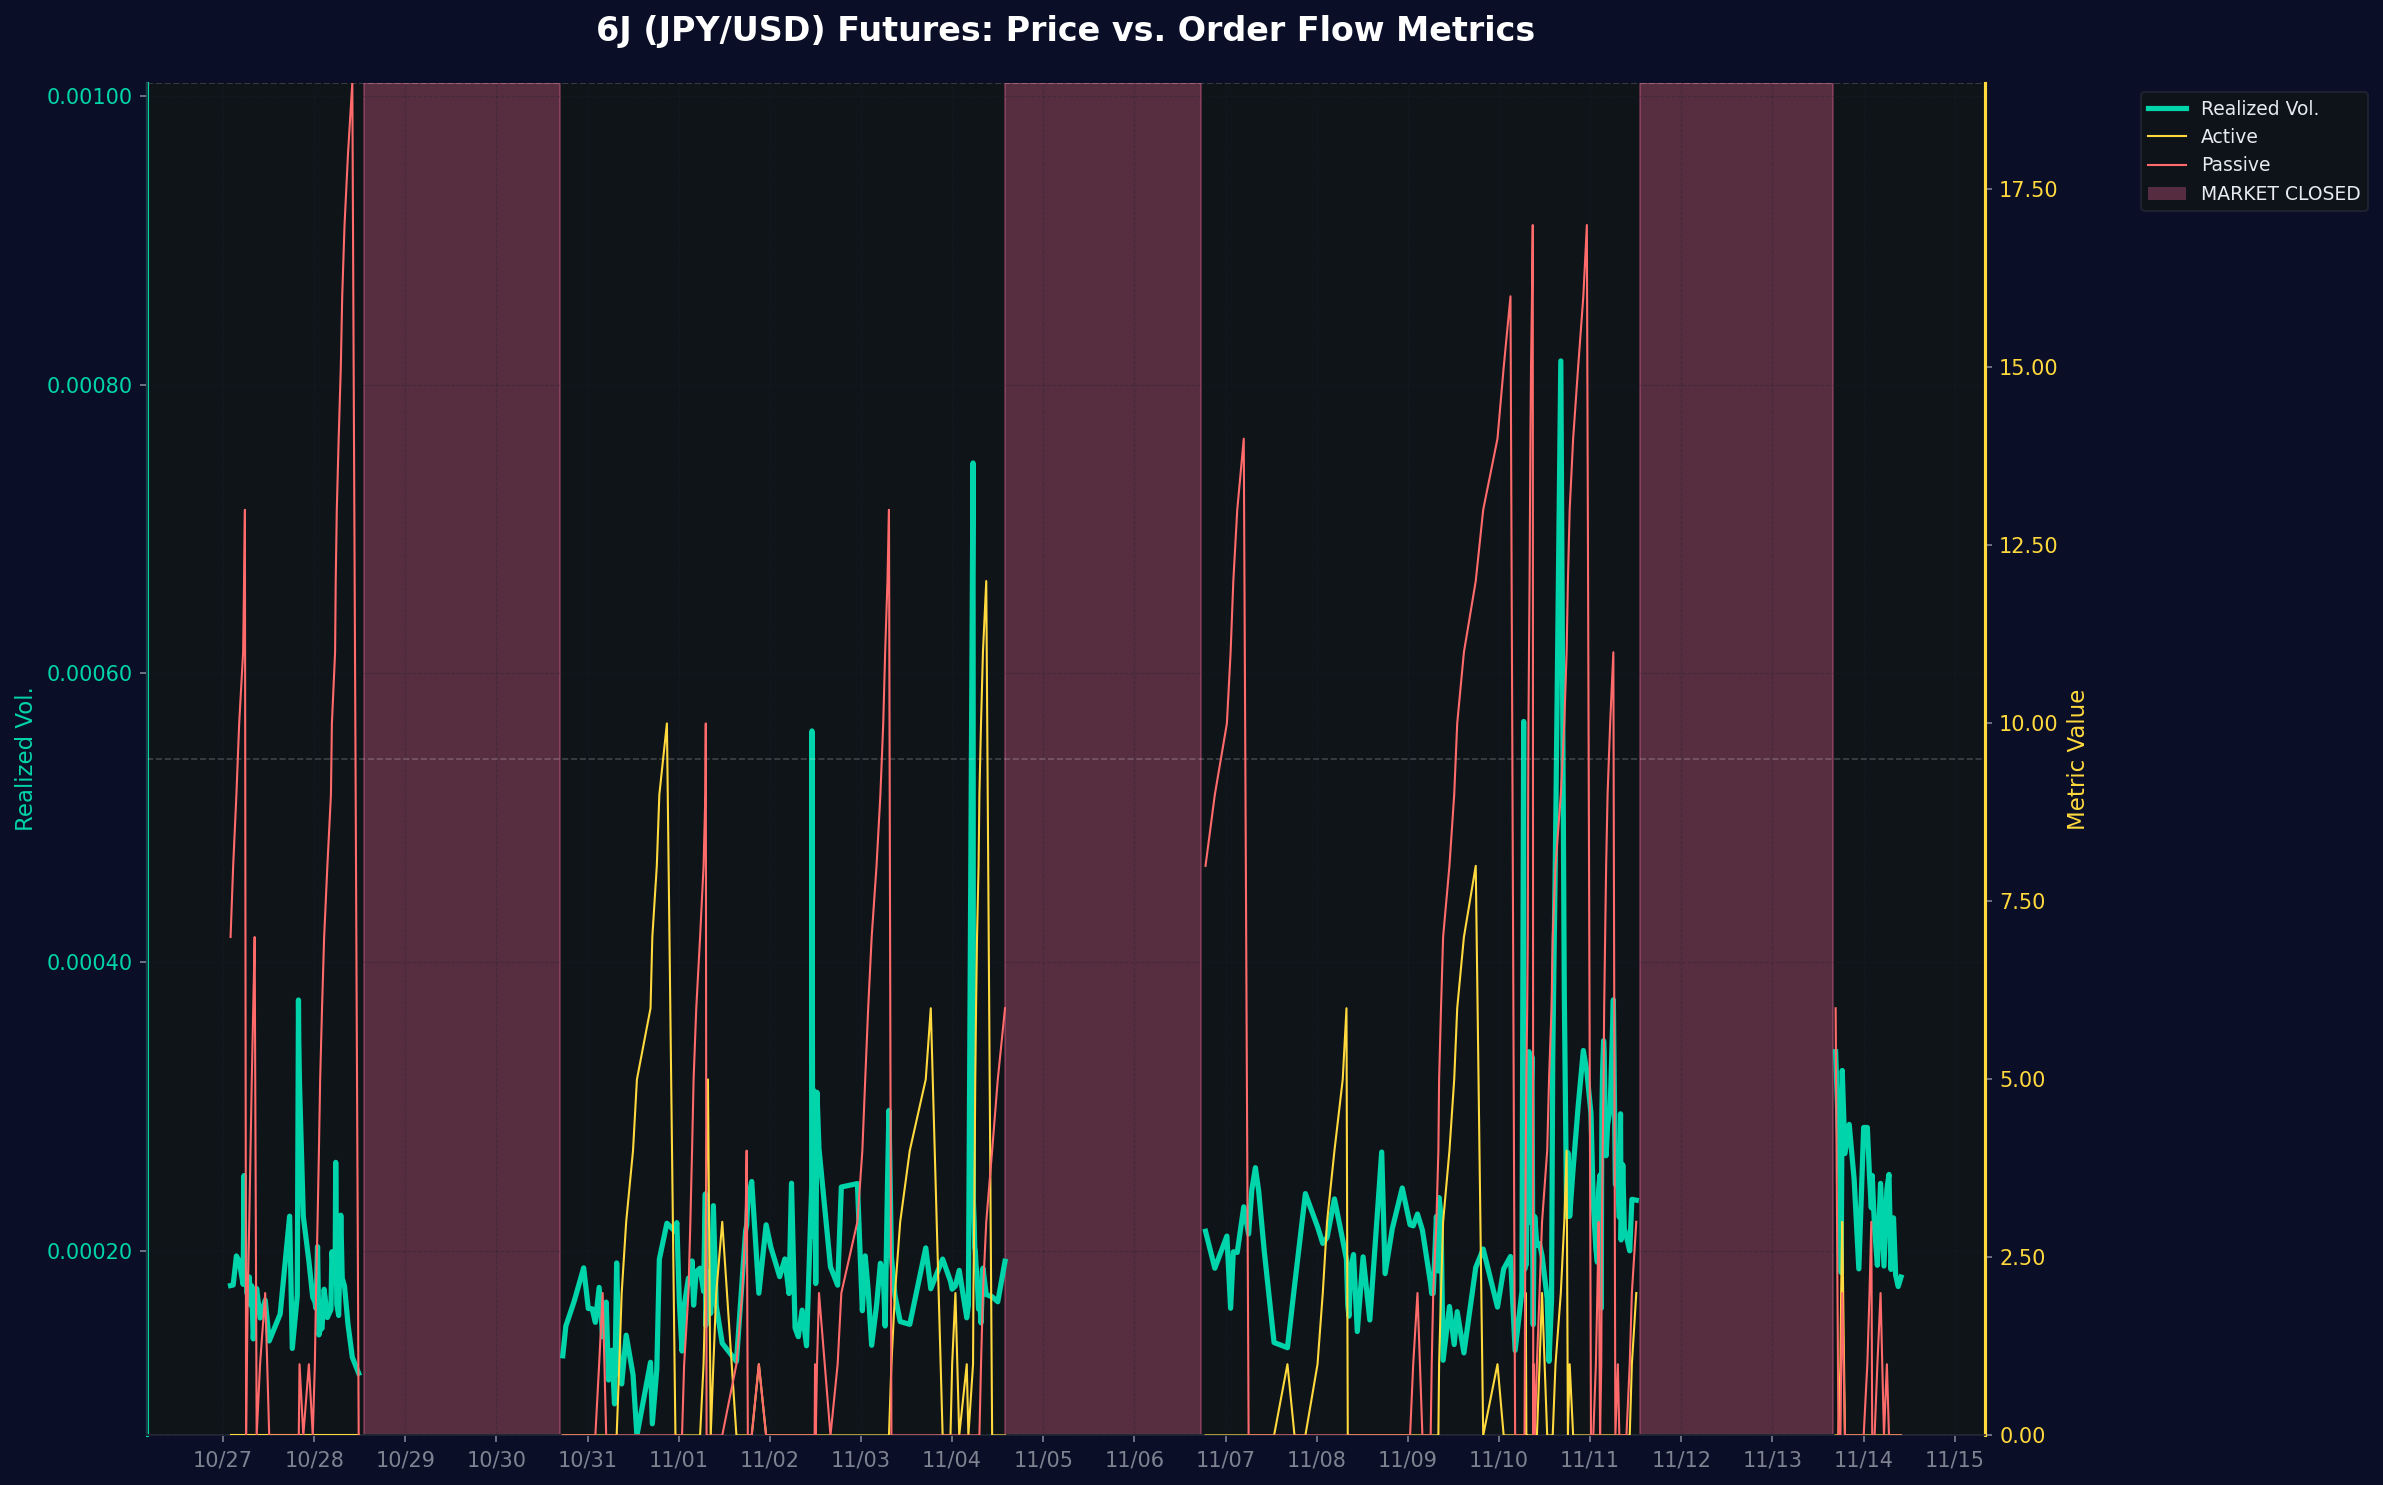

In [16]:
fig, (ax_price, ax_metrics) = plot_price_with_metrics(

    main_df=rolling_metrics_event,
    main_ts_col="end_ts_ns",
    main_col="delta_passive_midprice_log_std", #"passive_midprice",
    main_decimal_places=5,

    metrics_df=rolling_metrics_event,
    metrics_ts_col="end_ts_ns",
    metric_cols=["streak__ecdf__normalized__active_imbalance_abs_above_08", "streak__ecdf__normalized__passive_imbalance_abs_above_08"],
    metric_labels=["Active", "Passive"],
    # metric_range=(0, 1),

    title="6J (JPY/USD) Futures: Price vs. Order Flow Metrics",
    main_label="Realized Vol.",


    event_a_col="contract_roll_any",
    event_a_label="CONTRACT ROLL",

    event_b_col="gap_return_any",
    event_b_label="MARKET CLOSED",

    show_calculation_guides=False,
    step_lines=False,
)
plt.show()

In [17]:
"""

# Old / Manual Generation of Correlations

"""


# comparison1_var = "delta_passive_midprice_log_std"
# comparison1_label = "Intra Bucket Realized Vol"

# comparison2 = "" # etc



# # Prediction Windows
# lookahead = 25

# # Choices
# choice_1_a = "active"
# choice_2_p = "passive"

# # Text
# label_prefix = "_past_prediction__"
# metric_prefix = "ecdf__normalized__"
# type_prefix = "_imbalance_"

# # Absolute - 1
# variation_1 = "abs"
# a_cols = [f"lead{i}{label_prefix}{metric_prefix}{choice_1_a}{type_prefix}{variation_1}" for i in range(1, lookahead)]
# b_cols = [f"lead{i}{label_prefix}{metric_prefix}{choice_2_p}{type_prefix}{variation_1}" for i in range(1, lookahead)]

# # Signed - 2
# variation_2 = "signed"
# c_cols = [f"lead{i}{label_prefix}{metric_prefix}{choice_1_a}{type_prefix}{variation_2}" for i in range(1, lookahead)]
# d_cols = [f"lead{i}{label_prefix}{metric_prefix}{choice_2_p}{type_prefix}{variation_2}" for i in range(1, lookahead)]


# correlation_rolling_metrics = (
#     rolling_metric
#     .with_columns([

#         # [ COMPARISONS ]
#         # Generate Percent Return from Log Return
#         (pl.col("delta_passive_midprice_log_std").exp() - 1).abs().alias("delta_passive_midprice_pct_return_abs"),

#         # Absolute - Variation 1
#         *[pl.col(f"{metric_prefix}{choice_1_a}{type_prefix}{variation_1}").log().shift(key).alias(col) for key, col in enumerate(a_cols)],
#         *[pl.col(f"{metric_prefix}{choice_2_p}{type_prefix}{variation_1}").log().shift(key).alias(col) for key, col in enumerate(b_cols)],

#         # Signed - Variation 2
#         *[pl.col(f"{metric_prefix}{choice_1_a}{type_prefix}{variation_2}").log().shift(key).alias(col) for key, col in enumerate(c_cols)],
#         *[pl.col(f"{metric_prefix}{choice_2_p}{type_prefix}{variation_2}").log().shift(key).alias(col) for key, col in enumerate(d_cols)],

#     ])
#     .select([
#         "id",
#         comparison1_var,

#         *a_cols,
#         *b_cols,
#         *c_cols,
#         *d_cols,

#     ])
# ).collect()



# # [ CORRELATION FOR: variation_1 ]

# formatted_correlations_1 = pl.DataFrame({
#     f"{variation_1}_{choice_1_a}_Comparison": [f"{comparison1_label}_vs_last_vpin_{(key + 1)}" for key,col in enumerate(a_cols)],
#     f"{variation_1}_{choice_1_a}_CORRELATION": [correlation_rolling_metrics.select(pl.corr(comparison1_var, col)).item() for col in a_cols],
#     f"{variation_1}_{choice_2_p}_Comparison": [f"{comparison1_label}_vs_last_vpin_{(key + 1)}" for key,col in enumerate(b_cols)],
#     f"{variation_1}_{choice_2_p}_CORRELATION": [correlation_rolling_metrics.select(pl.corr(comparison1_var, col)).item() for col in b_cols],
# })

# print(formatted_correlations_1)

# # [ CORRELATION FOR: variation_2 ]

# formatted_correlations_2 = pl.DataFrame({
#     f"{variation_2}_{choice_1_a}_Comparison": [f"{comparison1_label}_vs_last_vpin_{(key + 1)}" for key,col in enumerate(c_cols)],
#     f"{variation_2}_{choice_1_a}_CORRELATION": [correlation_rolling_metrics.select(pl.corr(comparison1_var, col)).item() for col in c_cols],
#     f"{variation_2}_{choice_2_p}_Comparison": [f"{comparison1_label}_vs_last_vpin_{(key + 1)}" for key,col in enumerate(d_cols)],
#     f"{variation_2}_{choice_2_p}_CORRELATION": [correlation_rolling_metrics.select(pl.corr(comparison1_var, col)).item() for col in d_cols],
# })

# print(formatted_correlations_2)

'\n\n# Old / Manual Generation of Correlations\n\n'

In [18]:

comparison1_var = "delta_passive_midprice_log_std"
comparison1_label = "Intra Bucket Realized Vol"

comparison2 = "" # etc

# Prediction Windows
lookahead = 25

# Choices
choice_1_a = "buy_volume"
choice_2_p = "sell_volume"

# Text
label_prefix = "_past_prediction__"
metric_prefix = "ecdf__normalized__divergence_"
type_prefix = "_imbalance_"

# Buy - 1
variation_1 = "buy_volume"
a_cols = [f"lead{i}{label_prefix}{metric_prefix}{variation_1}" for i in range(1, lookahead)]

# Sell - 2
variation_2 = "sell_volume"
b_cols = [f"lead{i}{label_prefix}{metric_prefix}{variation_2}" for i in range(1, lookahead)]

# c_cols = [f"lead{i}{label_prefix}{metric_prefix}{choice_1_a}{type_prefix}{variation_2}" for i in range(1, lookahead)]
# d_cols = [f"lead{i}{label_prefix}{metric_prefix}{choice_2_p}{type_prefix}{variation_2}" for i in range(1, lookahead)]


correlation_rolling_metrics = (
    rolling_metric
    .with_columns([

        # [ COMPARISONS ]
        # Generate Percent Return from Log Return
        (pl.col("delta_passive_midprice_log_std").exp() - 1).abs().alias("delta_passive_midprice_pct_return_abs"),

        # Buy
        *[pl.col(f"{metric_prefix}{variation_1}").log().shift(key).alias(col) for key, col in enumerate(a_cols)],

        # Sell
        *[pl.col(f"{metric_prefix}{variation_2}").log().shift(key).alias(col) for key, col in enumerate(b_cols)],

    ])
    # .with_columns(
    #     # Attempt to compare signal to price direction
    #     pl.when(pl.col("delta_passive_midprice_pct_return_abs") < 0)
    #     .then(pl.col("delta_passive_midprice_log_std"))
    #     .otherwise(None)
    #     .alias("delta_passive_midprice_log_std_positive")

    # )
    # .filter(

    #     # Remove empty values
    #     pl.col("delta_passive_midprice_log_std_positive").is_not_null(),

    # )
    .select([
        "id",
        comparison1_var,

        *a_cols,
        *b_cols,

    ])
).collect()



# [ CORRELATION FOR: variation_1 ]

formatted_correlations_1 = pl.DataFrame({
    f"{variation_1}_Comparison": [f"{comparison1_label}_vs_last_vpin_{(key + 1)}" for key,col in enumerate(a_cols)],
    f"{variation_1}_CORRELATION": [correlation_rolling_metrics.select(pl.corr(comparison1_var, col)).item() for col in a_cols],
    f"{variation_2}_Comparison": [f"{comparison1_label}_vs_last_vpin_{(key + 1)}" for key,col in enumerate(b_cols)],
    f"{variation_2}_CORRELATION": [correlation_rolling_metrics.select(pl.corr(comparison1_var, col)).item() for col in b_cols],
})

print(formatted_correlations_1)

# [ CORRELATION FOR: variation_2 ]

# formatted_correlations_2 = pl.DataFrame({
#     f"{variation_2}_Comparison": [f"{comparison1_label}_vs_last_vpin_{(key + 1)}" for key,col in enumerate(c_cols)],
#     f"{variation_2}_CORRELATION": [correlation_rolling_metrics.select(pl.corr(comparison1_var, col)).item() for col in c_cols],
#     f"{variation_2}_Comparison": [f"{comparison1_label}_vs_last_vpin_{(key + 1)}" for key,col in enumerate(d_cols)],
#     f"{variation_2}_CORRELATION": [correlation_rolling_metrics.select(pl.corr(comparison1_var, col)).item() for col in d_cols],
# })

# print(formatted_correlations_2)

shape: (24, 4)
┌────────────────────────┬────────────────────────┬────────────────────────┬───────────────────────┐
│ buy_volume_Comparison  ┆ buy_volume_CORRELATION ┆ sell_volume_Comparison ┆ sell_volume_CORRELATI │
│ ---                    ┆ ---                    ┆ ---                    ┆ ON                    │
│ str                    ┆ f64                    ┆ str                    ┆ ---                   │
│                        ┆                        ┆                        ┆ f64                   │
╞════════════════════════╪════════════════════════╪════════════════════════╪═══════════════════════╡
│ Intra Bucket Realized  ┆ -0.125955              ┆ Intra Bucket Realized  ┆ 0.096061              │
│ Vol_vs_l…              ┆                        ┆ Vol_vs_l…              ┆                       │
│ Intra Bucket Realized  ┆ -0.120766              ┆ Intra Bucket Realized  ┆ 0.085487              │
│ Vol_vs_l…              ┆                        ┆ Vol_vs_l…              ┆

In [19]:

# ============================================================================
# CONFIGURATION
# ============================================================================

# Comparison Variables (add more as needed)
comparisons = [
    {"var": "delta_passive_midprice_log_std", "label": "Intra Bucket Realized Vol"},
    # {"var": "another_metric", "label": "Another Metric Description"},
    # Add more comparisons here
]

# Prediction Windows
lookahead = 25

# Choices (manually define these)
choices = ["active", "passive"]

# Variations (manually define these)
variations = ["abs", "signed"]

# Text patterns (manually define these)
label_prefix = "_past_prediction__"
metric_prefix = "ecdf__normalized__"
type_prefix = "_imbalance_"


# ============================================================================
# COLUMN GENERATION
# ============================================================================

# Generate column mappings for each choice-variation combination
column_mappings = {}
for choice in choices:
    for variation in variations:
        key = f"{choice}_{variation}"
        column_mappings[key] = {
            "source": f"{metric_prefix}{choice}{type_prefix}{variation}",
            "cols": [
                f"lead{i}{label_prefix}{metric_prefix}{choice}{type_prefix}{variation}" 
                for i in range(1, lookahead)
            ]
        }

# ============================================================================
# DATA TRANSFORMATION
# ============================================================================

# Build the with_columns expressions
expressions = []

# Add derived comparison metrics (manually add more as needed)
expressions.append(
    (pl.col("delta_passive_midprice_log_std").exp() - 1).abs().alias("delta_passive_midprice_pct_return_abs")
)

# Generate shifted columns for all choice-variation combinations
for key, mapping in column_mappings.items():
    source_col = mapping["source"]
    target_cols = mapping["cols"]
    expressions.extend([
        pl.col(source_col).log().shift(shift_amount).alias(col) for shift_amount, col in enumerate(target_cols)
    ])

# Build the select columns list
select_cols = ["id"] + [comp["var"] for comp in comparisons]
for mapping in column_mappings.values():
    select_cols.extend(mapping["cols"])

# Apply transformations
correlation_rolling_metrics = (
    rolling_metric
    .with_columns(expressions)
    .select(select_cols)
).collect()

# ============================================================================
# CORRELATION CALCULATION
# ============================================================================

# Calculate correlations for all combinations
correlation_results = []

for comp_idx, comparison in enumerate(comparisons):
    comp_var = comparison["var"]
    comp_label = comparison["label"]
    
    for variation in variations:
        for choice in choices:
            key = f"{choice}_{variation}"
            cols = column_mappings[key]["cols"]
            
            # Calculate correlations
            correlations = [
                correlation_rolling_metrics.select(pl.corr(comp_var, col)).item() #, method="spearman"
                for col in cols
            ]
            
            # Create comparison labels
            comparison_labels = [
                f"{comp_label}_vs_last_vpin_{(i + 1)}" 
                for i in range(len(cols))
            ]
            
            # Store results
            for i, (label, corr) in enumerate(zip(comparison_labels, correlations)):
                correlation_results.append({
                    "comparison_idx": comp_idx,
                    "comparison_var": comp_var,
                    "comparison_label": comp_label,
                    "variation": variation,
                    "choice": choice,
                    "lookback": i + 1,
                    "comparison_description": label,
                    "correlation": corr
                })

# Create master DataFrame
all_correlations = pl.DataFrame(correlation_results)

# ============================================================================
# OUTPUT SELECTION
# ============================================================================

def print_correlation_section(df, comparison_idx=0, variation=None):
    """
    Print a specific section of correlations.
    
    Parameters:
    - df: The all_correlations DataFrame
    - comparison_idx: Which comparison variable to show (0, 1, 2, etc.)
    - variation: Which variation to show ('abs', 'signed', or None for all)
    """
    filtered = df.filter(pl.col("comparison_idx") == comparison_idx)
    
    if variation is not None:
        filtered = filtered.filter(pl.col("variation") == variation)
    
    # Pivot for readable output
    result = filtered.pivot(
        values="correlation",
        index=["lookback", "comparison_description"],
        on="choice",
        aggregate_function="first"
    ).sort("lookback")
    
    return result

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

# # Print first comparison, abs variation
# print("=== Comparison 0: Absolute ===")
# print(print_correlation_section(all_correlations, comparison_idx=0, variation="abs"))

# print("\n=== Comparison 0: Signed ===")
# print(print_correlation_section(all_correlations, comparison_idx=0, variation="signed"))

# # Print all variations for first comparison
# print("\n=== Comparison 0: All Variations ===")
# print(print_correlation_section(all_correlations, comparison_idx=0))

# # Alternative: Filter the master DataFrame directly
# section_1_abs = all_correlations.filter(
#     (pl.col("comparison_idx") == 0) & 
#     (pl.col("variation") == "abs")
# )
# print("\n=== Direct Filter Example ===")
# print(section_1_abs)

In [20]:
# Print first comparison, abs variation
print("=== Comparison 0: Absolute ===")
print(print_correlation_section(all_correlations, comparison_idx=0, variation="abs"))


=== Comparison 0: Absolute ===
shape: (24, 4)
┌──────────┬─────────────────────────────────┬───────────┬──────────┐
│ lookback ┆ comparison_description          ┆ active    ┆ passive  │
│ ---      ┆ ---                             ┆ ---       ┆ ---      │
│ i64      ┆ str                             ┆ f64       ┆ f64      │
╞══════════╪═════════════════════════════════╪═══════════╪══════════╡
│ 1        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.070665 ┆ 0.343775 │
│ 2        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.061475 ┆ 0.333227 │
│ 3        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.060254 ┆ 0.321582 │
│ 4        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.059949 ┆ 0.312883 │
│ 5        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.058429 ┆ 0.309814 │
│ 6        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.060924 ┆ 0.305882 │
│ 7        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.058492 ┆ 0.303558 │
│ 8        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.061088 ┆ 0.299592 │
│ 9        ┆ Intra Bucket Realized Vol_vs_l…

In [21]:
print("\n=== Comparison 0: Signed ===")
print(print_correlation_section(all_correlations, comparison_idx=0, variation="signed"))



=== Comparison 0: Signed ===
shape: (24, 4)
┌──────────┬─────────────────────────────────┬───────────┬───────────┐
│ lookback ┆ comparison_description          ┆ active    ┆ passive   │
│ ---      ┆ ---                             ┆ ---       ┆ ---       │
│ i64      ┆ str                             ┆ f64       ┆ f64       │
╞══════════╪═════════════════════════════════╪═══════════╪═══════════╡
│ 1        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.020483 ┆ 0.035401  │
│ 2        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.022415 ┆ 0.02538   │
│ 3        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.02405  ┆ 0.012001  │
│ 4        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.024804 ┆ 0.007104  │
│ 5        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.025985 ┆ 0.00594   │
│ 6        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.029141 ┆ 0.00442   │
│ 7        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.032475 ┆ 0.002012  │
│ 8        ┆ Intra Bucket Realized Vol_vs_l… ┆ -0.034818 ┆ 0.003203  │
│ 9        ┆ Intra Bucket Realiz

ecdf__normalized__passive_imbalance_abs is correlated with delta_passive_midprice_log_std -> passive or active? there was an error

Typically 0.4 - 0.3 between the previous 1 - 25 predictions

ROBUST across bucket length lookback periods of 50-300, even correlated at 10% when lookback is 1-2 buckets

I think the signed imbalance is even stronger for passive

Accross all configurations it was weakly negatively correlated

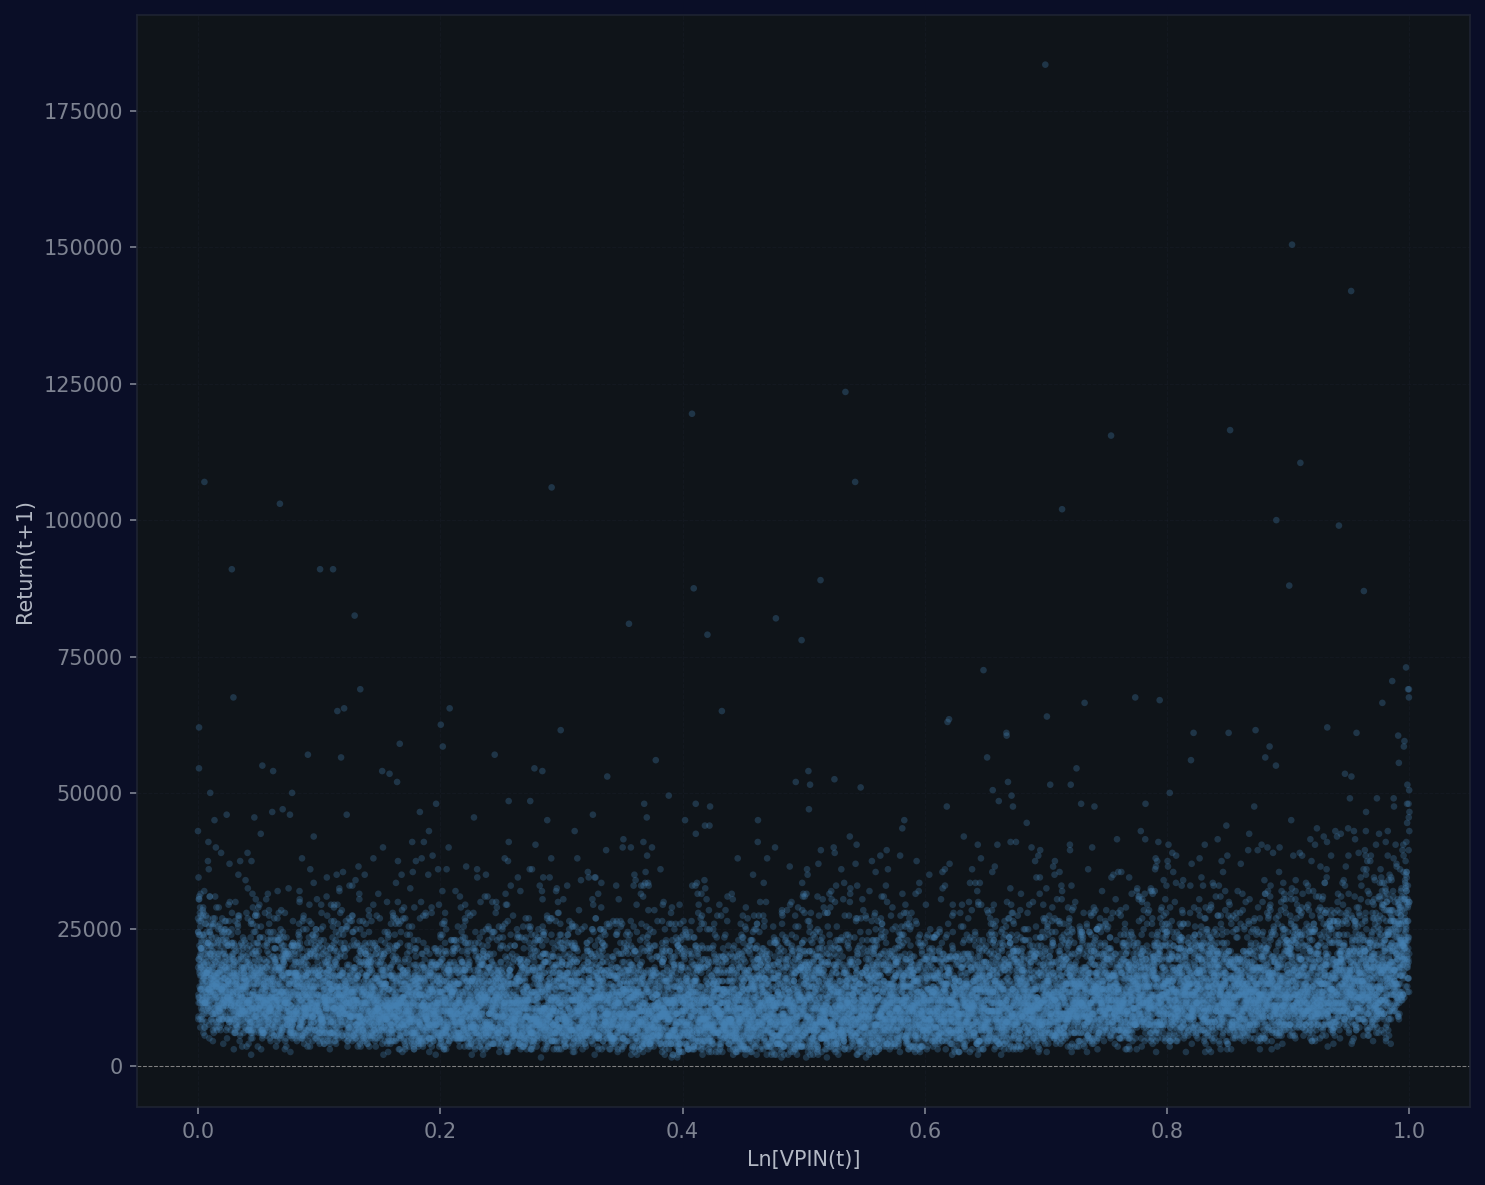

In [ ]:

# # Filter out nulls and infinities for plotting
# plot_df = df.filter(
#     pl.col("ln_vpin").is_finite() & pl.col("return_t1").is_not_null()
# )

# Extract as numpy for matplotlib
df = rolling_metric.collect()
y = df["delta_passive_midprice_log_std"].to_numpy()
x = df["ecdf__normalized__passive_imbalance_abs"].to_numpy()

# Create the scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(x, y, alpha=0.3, s=10, c="steelblue", edgecolors="none")

ax.set_xlabel("Ln[VPIN(t)]")
ax.set_ylabel("Return(t+1)")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig("vpin_return_scatter.png", dpi=150)
plt.show()

In [ ]:
"""
scale to scale graph

log log

delta_passive_midprice_pct_return_abs

"""

'\nscale to scale graph\n\nlog log\n\ndelta_passive_midprice_pct_return_abs\n\n'

graphs to make...

In [ ]:
"""

Search grid of lookback and lead...?

"""

'\n\nSearch grid of lookback and lead...?\n\n'